<a href="https://colab.research.google.com/github/Mikolaj-13/lecture1/blob/main/PUM10_systemy_rekomendacyjne_cz2_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dane https://grouplens.org/datasets/movielens/32m/


In [2]:
ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())
movies = pd.read_csv('/content/movies.csv')


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


Wczytanie plikow z selekcja uzytkownikow - tylko dla cwiczenia cz2. w celu redukcji danych

In [3]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
print(ratings.head())

movies = pd.read_csv('/content/movies.csv')

# policz liczbę ocen na użytkownika
user_activity = ratings['userId'].value_counts()

# wybierz 100 najbardziej aktywnych użytkowników
top_users = user_activity.head(100).index

# przefiltruj dane
ratings = ratings[ratings['userId'].isin(top_users)]

# opcjonalnie sprawdź wynik
print("Liczba rekordów po filtracji:", len(ratings))
print("Liczba użytkowników:", ratings['userId'].nunique())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Liczba rekordów po filtracji: 60784
Liczba użytkowników: 100


Poznaj dane:


1.   Ile jest ocen filmów?
2.   Ile filmów w bazie?
3.   Ile użytkowników?
4.   Jaka jest średnia liczba ocen na użytkownika i na film?



In [4]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
#n_movies = movies['movieId'].nunique()
n_users = len(ratings['userId'].unique())

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 60784
Number of unique movieId's: 9123
Number of unique users: 100
Average number of ratings per user: 607.84
Average number of ratings per movie: 6.66


Jak wygląda rozkład ocen filmów?




/tmp/ipykernel_8571/2038653828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=ratings, palette="viridis")


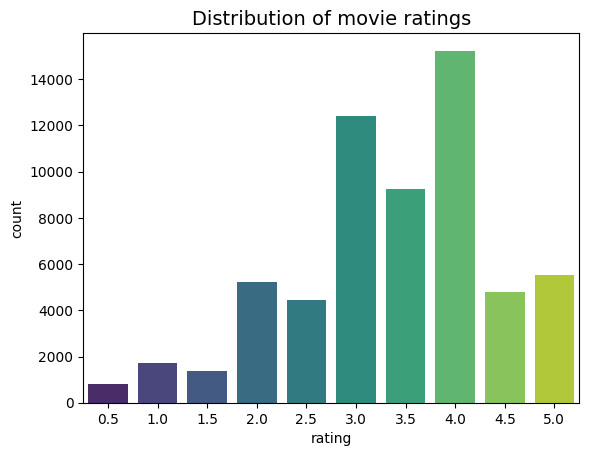

In [5]:
sns.countplot(x="rating", data=ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [6]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
Forrest Gump (1994),93
Star Wars: Episode IV - A New Hope (1977),87
"Matrix, The (1999)",86
Star Wars: Episode V - The Empire Strikes Back (1980),84
Pulp Fiction (1994),83
Star Wars: Episode VI - Return of the Jedi (1983),81
"Silence of the Lambs, The (1991)",80
Jurassic Park (1993),78
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),78


In [7]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.38.
Mean rating per user: 3.47.


In [8]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
print(movies[movies['movieId']==lowest_rated])
highest_rated = mean_ratings['rating'].idxmax()
print(movies[movies['movieId'] == highest_rated])

      movieId                                title  genres
1014     1325  Amityville: A New Generation (1993)  Horror
    movieId            title           genres
48       53  Lamerica (1994)  Adventure|Drama


In [9]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [10]:
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [11]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']

movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
movie_stats.describe()

,movieId,count,mean,bayesian_avg
count,9123.000000,9123.000000,9123.000000,9123.000000
mean,41366.080675,6.662721,3.203141,3.221962
std,51442.472183,10.632276,0.875346,0.265699
min,1.000000,1.000000,0.500000,2.017402
25%,3176.500000,1.000000,2.666667,3.046128
50%,7175.000000,2.000000,3.333333,3.241881
75%,74455.000000,7.000000,3.833333,3.372383
max,190183.000000,93.000000,5.000000,4.350113


In [12]:
movie_ratings['movieId'].nunique()
M = movie_ratings['userId'].nunique()
user_mapper = dict(zip(np.unique(movie_ratings["userId"]), list(range(M))))

In [13]:
from scipy.sparse import csr_matrix

def create_sparse(df):
    """
    Generates a sparse matrix from ratings dataframe.

    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)

    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M,N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_sparse(ratings)

In [14]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 6.66%


Wykorzystaj algorytm najblizszych sąsiadów, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

In [32]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []

    X_movies = X.T

    target_movie_idx = movie_mapper[movie_id]

    target_movie_vec = X_movies[target_movie_idx]

    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X_movies)

    if isinstance(target_movie_vec, (np.ndarray)):
        target_movie_vec = target_movie_vec.reshape(1,-1)

    if show_distance:
        distances, indices = kNN.kneighbors(target_movie_vec, return_distance=True)
    else:
        indices = kNN.kneighbors(target_movie_vec, return_distance=False)

    for i in range(1, len(indices[0])):
        idx = indices[0][i]
        neighbour_ids.append(movie_inv_mapper[idx])

    return neighbour_ids

In [16]:
movie_titles = dict(zip(movies['movieId'], movies['title']))
movie_id = 1

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched Toy Story (1995)
Jurassic Park (1993)
Star Wars: Episode IV - A New Hope (1977)
Star Wars: Episode V - The Empire Strikes Back (1980)
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)
Star Wars: Episode VI - Return of the Jedi (1983)
Back to the Future (1985)
Matrix, The (1999)
Shrek (2001)
Groundhog Day (1993)
Indiana Jones and the Last Crusade (1989)


In [18]:
U_svd, s_svd, Vh_svd = np.linalg.svd(X.toarray(), full_matrices=False)
movie_features_svd = Vh_svd.T

from sklearn.metrics.pairwise import cosine_similarity

def find_similar_movies_svd(movie_id, movie_features, movie_mapper, movie_inv_mapper, k=10):
    target_movie_idx = movie_mapper[movie_id]
    target_movie_vec = movie_features[target_movie_idx].reshape(1, -1)
    similarities = cosine_similarity(target_movie_vec, movie_features).flatten()
    similar_indices = similarities.argsort()[::-1][1:k+1]
    similar_movie_ids_svd = [movie_inv_mapper[idx] for idx in similar_indices]
    return similar_movie_ids_svd

movie_id_for_svd_recommendation = 1

similar_ids_svd = find_similar_movies_svd(
    movie_id_for_svd_recommendation,
    movie_features_svd,
    movie_mapper,
    movie_inv_mapper,
    k=10
)

movie_title_for_svd = movie_titles[movie_id_for_svd_recommendation]

print(f"\nPonieważ obejrzałeś {movie_title_for_svd} (rekomendacje SVD):")
for movie_id_rec in similar_ids_svd:
    print(movie_titles[movie_id_rec])


Ponieważ obejrzałeś Toy Story (1995) (rekomendacje SVD):
Toy Story 3 (2010)
Jurassic Park (1993)
Mask, The (1994)
Shrek (2001)
Ice Age (2002)
Lion King, The (1994)
Babe (1995)
Toy Story 2 (1999)
Peter Pan (1953)
Sully (2016)


Wykorzystaj algorytm SVD, żeby podać 10 filmów po obejrzeniu *Toy* *Story*

cz1: klasyczne SVD (biblioteka **NumPy**)

In [33]:
import numpy as np

def svd_reconstruct(R, k=2):
    U, s, Vh = np.linalg.svd(R, full_matrices=False)
    S_k[:k, :k] = np.diag(s[:k])
    R_approx = U[:, :k] @ S_k @ Vh[:k, :]
    return R_approx

cz2: TruncatedSVD (scikit-learn)


In [34]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def truncated_svd_reconstruct(R, k=2):
    svd = TruncatedSVD(n_components=k)
    R_reduced = svd.fit_transform(R)
    R_approx = svd.inverse_transform(R_reduced)
    return R_approx

wywołaj obie funkcje i stworz rekomentacje dla uzytkownika nr 10

In [39]:
import numpy as np
from sklearn.decomposition import TruncatedSVD

def svd_reconstruct(R, k=2):
    U, s, Vh = np.linalg.svd(R, full_matrices=False)
    S_k = np.zeros((k, k))
    S_k[:k, :k] = np.diag(s[:k])
    R_approx = U[:, :k] @ S_k @ Vh[:k, :]
    return R_approx

def truncated_svd_reconstruct(R, k=2):
    svd = TruncatedSVD(n_components=k)
    R_reduced = svd.fit_transform(R)
    R_approx = svd.inverse_transform(R_reduced)
    return R_approx

user_id = list(user_mapper.keys())[9]
user_idx = user_mapper[user_id]

R_svd = svd_reconstruct(X.toarray(), k=20)
R_trunc = truncated_svd_reconstruct(X, k=20)

def get_recommendations(R_original, R_pred, user_idx, n_recommendations=10):
    user_ratings = R_original[user_idx, :].toarray().flatten()
    user_pred_ratings = R_pred[user_idx, :]
    unrated_movie_indices = np.where(user_ratings == 0)[0]
    unrated_movie_pred_ratings = user_pred_ratings[unrated_movie_indices]
    unrated_original_movie_ids = [movie_inv_mapper[idx] for idx in unrated_movie_indices]
    recommendations = list(zip(unrated_original_movie_ids, unrated_movie_pred_ratings))
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:n_recommendations]

recs_svd = get_recommendations(X, R_svd, user_mapper[user_id])
recs_trunc = get_recommendations(X, R_trunc, user_mapper[user_id])

print(f"Top 10 rekomendacji dla użytkownika {user_id} (klasyczne SVD):")
for movie_id_rec, rating_pred in recs_svd:
    print(f"{movie_titles[movie_id_rec]} {rating_pred:.2f}")

print("-------------------------------")

print(f"Top 10 rekomendacji dla użytkownika {user_id} (Truncated SVD):")
for movie_id_rec, rating_pred in recs_trunc:
    print(f"{movie_titles[movie_id_rec]} {rating_pred:.2f}")


Top 10 rekomendacji dla użytkownika 57 (klasyczne SVD):
Alien (1979) 3.76
E.T. the Extra-Terrestrial (1982) 3.55
Jaws (1975) 3.32
When Harry Met Sally... (1989) 3.22
From Russia with Love (1963) 3.21
Platoon (1986) 3.13
Reservoir Dogs (1992) 3.04
Stand by Me (1986) 2.97
Great Escape, The (1963) 2.75
Stripes (1981) 2.74
-------------------------------
Top 10 rekomendacji dla użytkownika 57 (Truncated SVD):
Alien (1979) 3.62
E.T. the Extra-Terrestrial (1982) 3.56
When Harry Met Sally... (1989) 3.36
Jaws (1975) 3.30
Reservoir Dogs (1992) 3.25
From Russia with Love (1963) 2.90
Platoon (1986) 2.88
Stand by Me (1986) 2.88
Deliverance (1972) 2.67
Psycho (1960) 2.65


KLUCZOWA różnica (najważniejsze)
SVD:

* działa na pełnej macierzy
* traktuje brak ocen jako 0 → to jest BŁĄD modelowy

TruncatedSVD:

* działa na macierzy sparse
* ale nadal NIE rozróżnia: brak oceny vs słaba ocena



Ocena modeli - policz RSME na macierzach tylko na niezerowych elementach

In [36]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

row_indices, col_indices = X.nonzero()
actual_ratings = X.data

predicted_ratings_svd = R_svd[row_indices, col_indices]
predicted_ratings_trunc = R_trunc[row_indices, col_indices]

rmse_svd = rmse(actual_ratings, predicted_ratings_svd)
print(f"RMSE for Classical SVD (on non-zero elements): {rmse_svd:.4f}")

rmse_trunc = rmse(actual_ratings, predicted_ratings_trunc)
print(f"RMSE for Truncated SVD (on non-zero elements): {rmse_trunc:.4f}")

RMSE for Classical SVD (on non-zero elements): 1.7836
RMSE for Truncated SVD (on non-zero elements): 1.7830
